# PIRVN — Baselines & Traditional ML

Predict product prices (VND) from text descriptions.

In [3]:
import json
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.feature_extraction.text import HashingVectorizer
from xgboost import XGBRegressor
import joblib
import matplotlib.pyplot as plt

In [4]:
train_path = Path("../phase2_curation/curated_data/train.json")
test_path  = Path("../phase2_curation/curated_data/test.json")

with open(train_path, encoding="utf-8") as f:
    train_data = json.load(f)

with open(test_path, encoding="utf-8") as f:
    test_data = json.load(f)

X_train_text = [item["full"] for item in train_data]
y_train      = np.array([item["price"] for item in train_data], dtype=float)

X_test_text  = [item["full"] for item in test_data]
y_test       = np.array([item["price"] for item in test_data], dtype=float)

print(f"Train samples : {len(X_train_text):,}")
print(f"Test  samples : {len(X_test_text):,}")
print(f"Train price range: {y_train.min():,.0f} – {y_train.max():,.0f} VND")
print(f"Test  price range: {y_test.min():,.0f} – {y_test.max():,.0f} VND")

Train samples : 9,428
Test  samples : 1,768
Train price range: 500,000 – 49,990,000 VND
Test  price range: 500,000 – 49,990,000 VND


In [5]:
vectorizer = HashingVectorizer(n_features=5000, stop_words=None)

X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")

X_train shape: (9428, 5000)
X_test  shape: (1768, 5000)


## Constant Baseline

In [6]:
constant_pred = np.full_like(y_test, fill_value=y_train.mean())
mae_constant  = mean_absolute_error(y_test, constant_pred)

print(f"Constant Baseline MAE: {mae_constant:,.0f} VND")

Constant Baseline MAE: 9,031,483 VND


## Linear Regression

In [7]:
Path("models").mkdir(exist_ok=True)

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
mae_lr  = mean_absolute_error(y_test, lr_pred)
r2_lr   = r2_score(y_test, lr_pred)

print(f"Linear Regression  MAE: {mae_lr:,.0f} VND  |  R²: {r2_lr:.4f}")

joblib.dump(lr, "models/linear_regression.joblib")
print("Model saved to models/linear_regression.joblib")

Linear Regression  MAE: 6,535,458 VND  |  R²: 0.1495
Model saved to models/linear_regression.joblib


## Random Forest

In [8]:
rf = RandomForestRegressor(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
mae_rf  = mean_absolute_error(y_test, rf_pred)
r2_rf   = r2_score(y_test, rf_pred)

print(f"Random Forest      MAE: {mae_rf:,.0f} VND  |  R²: {r2_rf:.4f}")

joblib.dump(rf, "models/random_forest.joblib")
print("Model saved to models/random_forest.joblib")

Random Forest      MAE: 4,338,108 VND  |  R²: 0.6664
Model saved to models/random_forest.joblib


## XGBoost

In [9]:
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
mae_xgb  = mean_absolute_error(y_test, xgb_pred)
r2_xgb   = r2_score(y_test, xgb_pred)

print(f"XGBoost            MAE: {mae_xgb:,.0f} VND  |  R²: {r2_xgb:.4f}")

joblib.dump(xgb, "models/xgboost.joblib")
print("Model saved to models/xgboost.joblib")

XGBoost            MAE: 3,741,724 VND  |  R²: 0.7293
Model saved to models/xgboost.joblib


## Leaderboard

Rank   Model                           MAE (VND)
--------------------------------------------------
1      XGBoost                         3,741,724
2      Random Forest                   4,338,108
3      Linear Regression               6,535,458
4      Constant Baseline               9,031,483


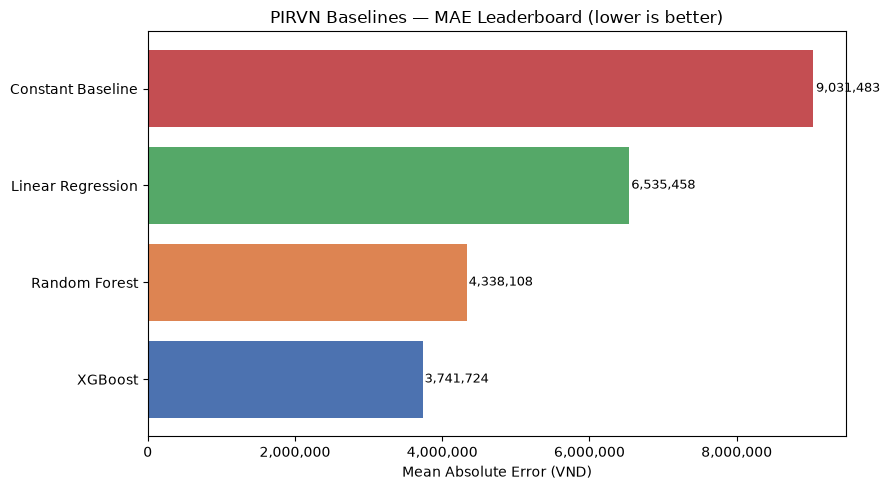

Chart saved to models/leaderboard.png


In [10]:
results = [
    ("Constant Baseline",  mae_constant),
    ("Linear Regression",  mae_lr),
    ("Random Forest",       mae_rf),
    ("XGBoost",             mae_xgb),
]

# Sort best (lowest MAE) first
results_sorted = sorted(results, key=lambda x: x[1])

print(f"{'Rank':<6} {'Model':<22} {'MAE (VND)':>18}")
print("-" * 50)
for rank, (name, mae) in enumerate(results_sorted, start=1):
    print(f"{rank:<6} {name:<22} {mae:>18,.0f}")

# Bar chart
model_names = [r[0] for r in results_sorted]
mae_values  = [r[1] for r in results_sorted]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(model_names, mae_values, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])

ax.set_xlabel("Mean Absolute Error (VND)")
ax.set_title("PIRVN Baselines — MAE Leaderboard (lower is better)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

for bar, val in zip(bars, mae_values):
    ax.text(
        bar.get_width() * 1.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,.0f}",
        va="center", fontsize=9
    )

plt.tight_layout()
plt.savefig("models/leaderboard.png", dpi=150)
plt.show()
print("Chart saved to models/leaderboard.png")